In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Updated working URL for the IBM Automobile Sales dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

# Load the dataset directly into pandas
df = pd.read_csv(URL)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import requests
import io

# Direct working link to the IBM Automobile Sales dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

# Fetch data using requests to bypass HTTP 404/SSL issues
response = requests.get(URL)
df = pd.read_csv(io.StringIO(response.text))

# Display first 5 rows to confirm it loaded
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


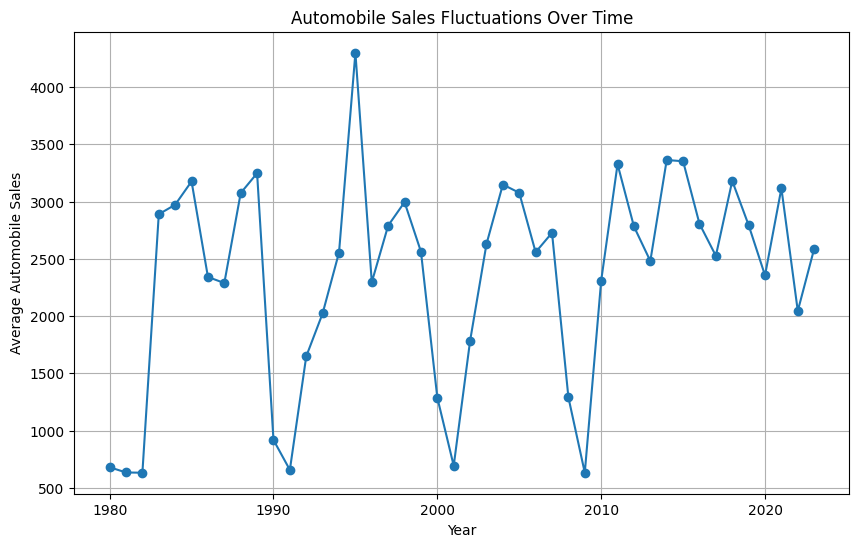

In [ ]:
df_line = df.groupby('Year')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(df_line['Year'], df_line['Automobile_Sales'], marker='o')
plt.title('Automobile Sales Fluctuations Over Time')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.grid(True)
plt.show()

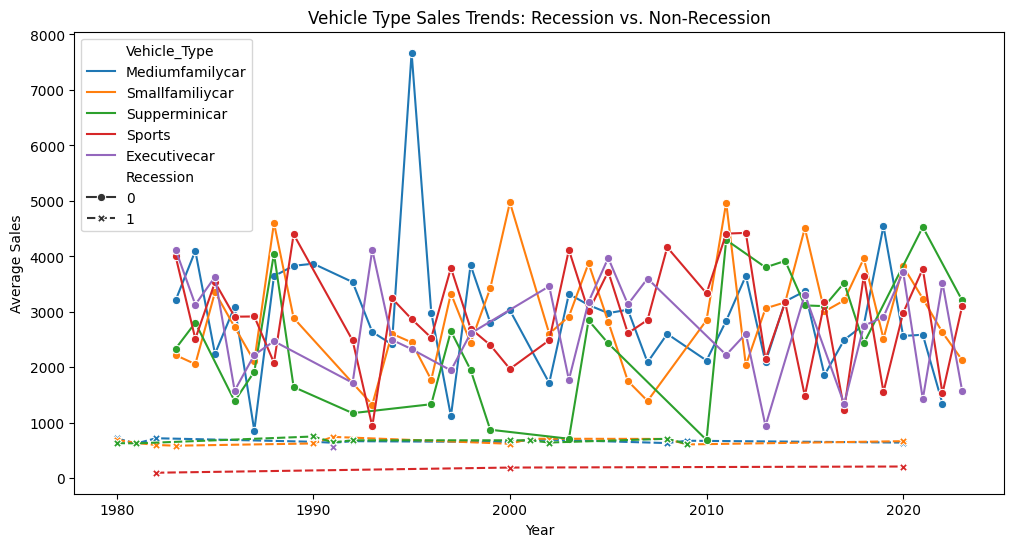

In [ ]:
df_Mline = df.groupby(['Year', 'Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_Mline, x='Year', y='Automobile_Sales', hue='Vehicle_Type', style='Recession', markers=True)
plt.title('Vehicle Type Sales Trends: Recession vs. Non-Recession')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.show()

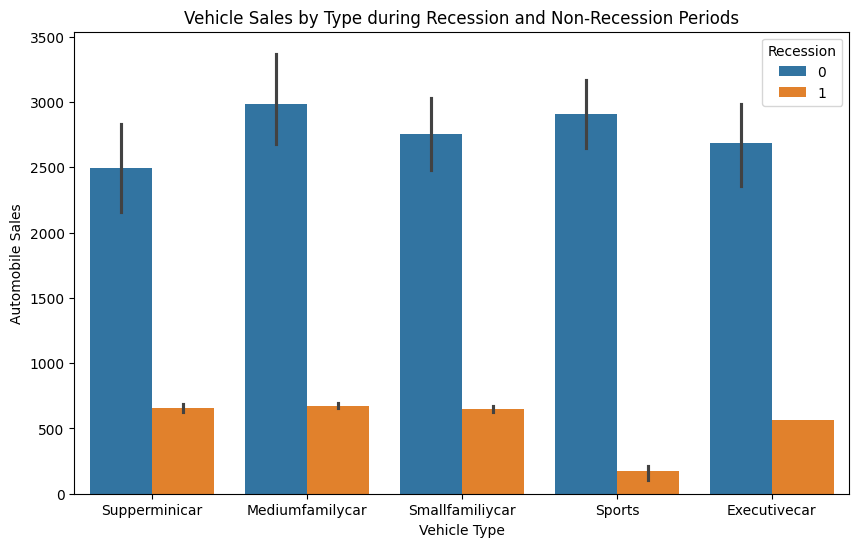

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')
plt.title('Vehicle Sales by Type during Recession and Non-Recession Periods')
plt.xlabel('Vehicle Type')
plt.ylabel('Automobile Sales')
plt.show()

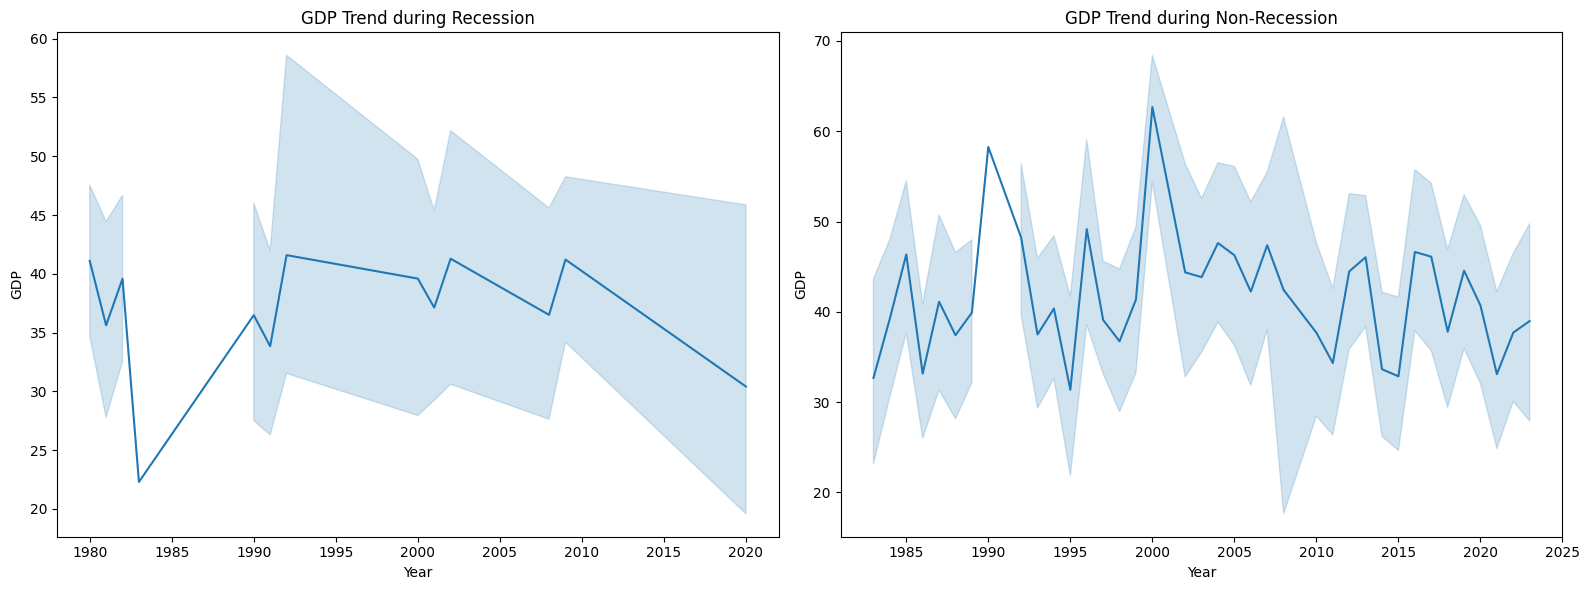

In [ ]:
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=rec_data, x='Year', y='GDP', ax=axes[0])
axes[0].set_title('GDP Trend during Recession')

sns.lineplot(data=non_rec_data, x='Year', y='GDP', ax=axes[1])
axes[1].set_title('GDP Trend during Non-Recession')

plt.tight_layout()
plt.show()

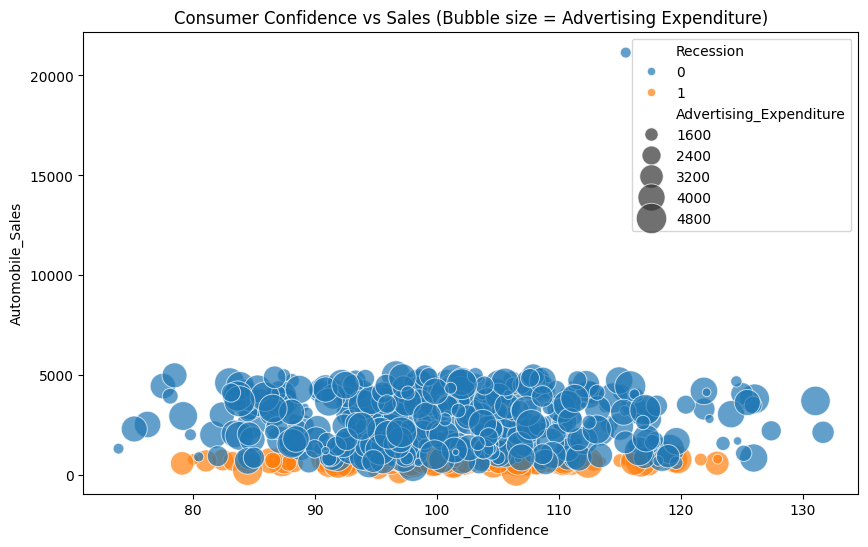

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Consumer_Confidence',
    y='Automobile_Sales',
    size='Advertising_Expenditure',
    hue='Recession',
    sizes=(20, 500),
    alpha=0.7
)
plt.title('Consumer Confidence vs Sales (Bubble size = Advertising Expenditure)')
plt.show()

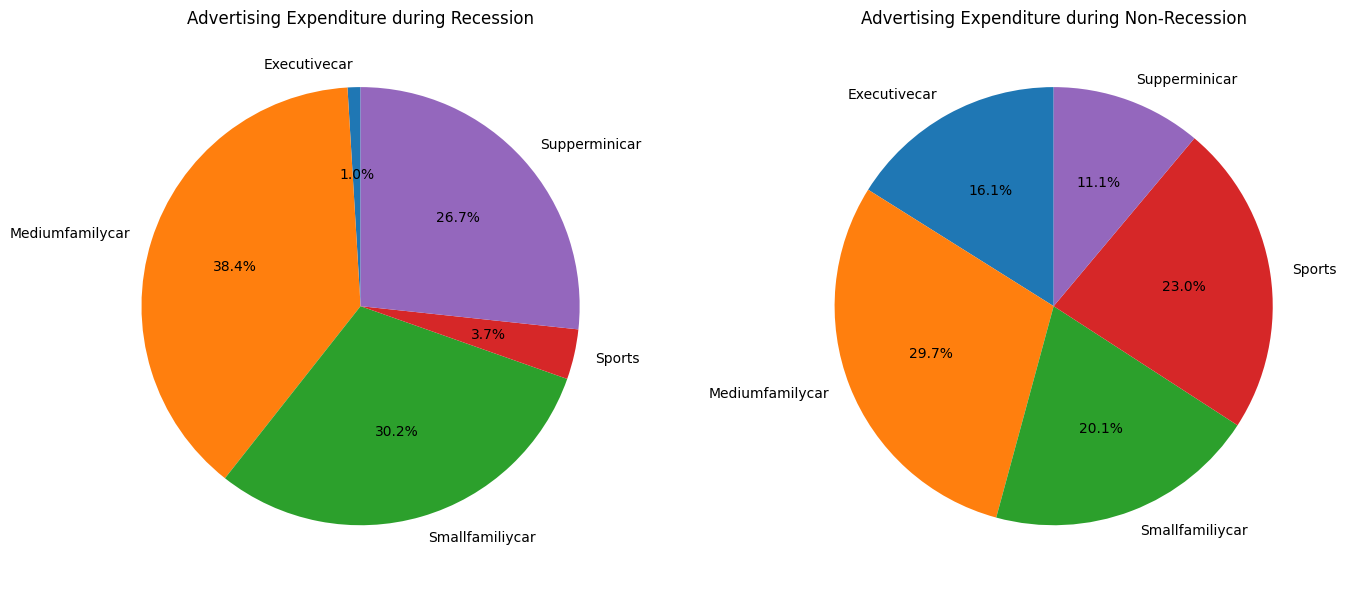

In [ ]:
rec_adv = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
non_rec_adv = non_rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(rec_adv, labels=rec_adv.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Advertising Expenditure during Recession')

axes[1].pie(non_rec_adv, labels=non_rec_adv.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Advertising Expenditure during Non-Recession')

plt.tight_layout()
plt.show()

In [ ]:
# Create interactive map
site_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Sample state locations for visualization
states_data = [
    {"name": "New York", "lat": 40.7128, "lon": -74.0060, "sales": 500},
    {"name": "California", "lat": 36.7783, "lon": -119.4179, "sales": 800},
    {"name": "Texas", "lat": 31.9686, "lon": -99.9018, "sales": 650}
]

for state in states_data:
    folium.CircleMarker(
        location=[state["lat"], state["lon"]],
        radius=state["sales"] / 50,
        color='blue',
        fill=True,
        fill_color='blue',
        popup=f"{state['name']}: {state['sales']} Units Sold"
    ).add_to(site_map)

site_map